In [5]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [133]:
pgroup = 'p23106'
runlist = [88,89,109]
t0_offsets = [0]*len(runlist)

data, meta = merge_multiple_runs(pgroup, runlist, t0_offset=t0_offsets)

Processing run 88


100%|██████████| 79/79 [00:09<00:00,  8.37it/s]


Processing run 89


100%|██████████| 79/79 [00:09<00:00,  8.15it/s]


Processing run 109


100%|██████████| 79/79 [00:07<00:00, 10.31it/s]


In [98]:
#data['scanvar'] = [d - c for d,c in zip(data['scanvar'], mm2fs(data['delay_GG_pump'], np.mean(np.array(data['delay_GG_pump']))))]
#data.keys()
#meta['xlabel']

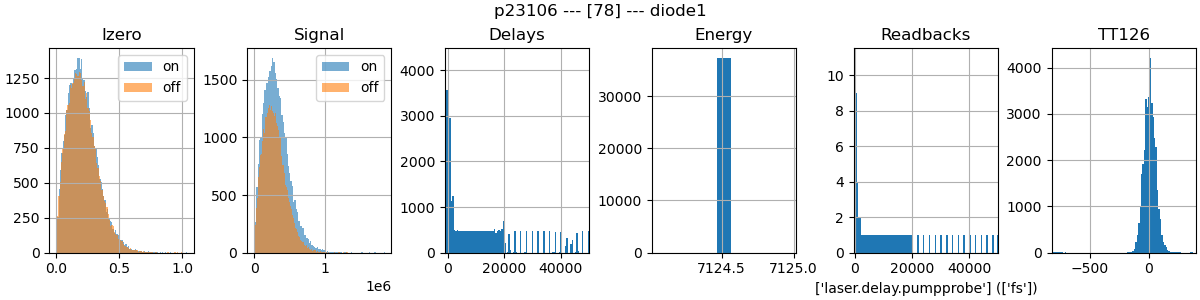

In [101]:
plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='126', withTT=True)#, bins=100, figsize=(12, 3))
#plot_merged_data(data, meta, Signal='diode2', Izero='diode1', TT='126', withTT=True)#, bins=100, figsize=(12, 3))

In [134]:
ui, out  = Rebin_widget(data=data)
ui

In [90]:
### --- To run manually instead of ui --- ###

# base_params = {'izero': 'Izero122', 'quantile': 0.7, 'TT': '126', 'YAGscan': False, 'withTT': False}
# meta_params = {'signal1': 'diode1', 'signal2': 'diode2'}

# results1 = Rebin_with_scanvar_and_filter(signal='diode1', data=data, **base_params)
# results2 = Rebin_with_scanvar_and_filter(signal='diode2', data=data, **base_params)
# out['signal1'] = {"results": results1, "params": base_params, "which": 'diode1'}
# out['signal2'] = {"results": results2, "params": base_params, "which": 'diode2'}

In [135]:
data_plot1 = out["signal1"]
data_plot2 = out["signal2"]
#fig, axes = plotter.bins_population(data_plot1, meta)
#fig, axes = plotter.shot_noise(data_plot1, meta)

/sf/alvra/data/p23106/work/Reduced_data/
Data saved in /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0078/


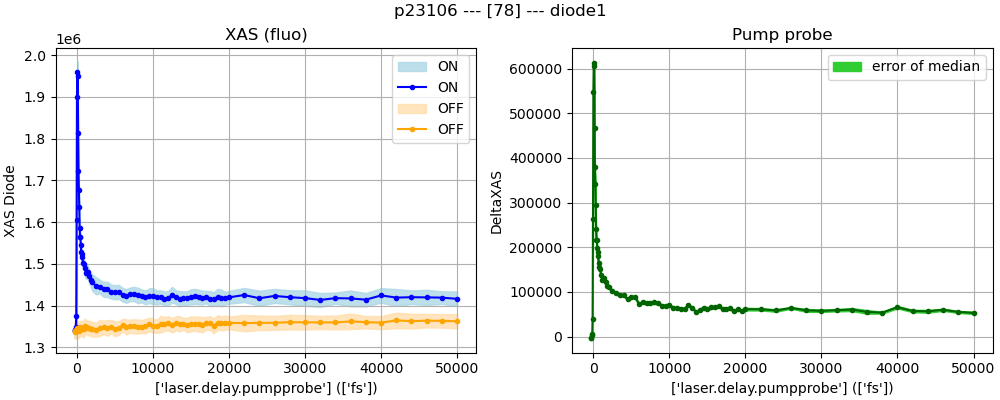

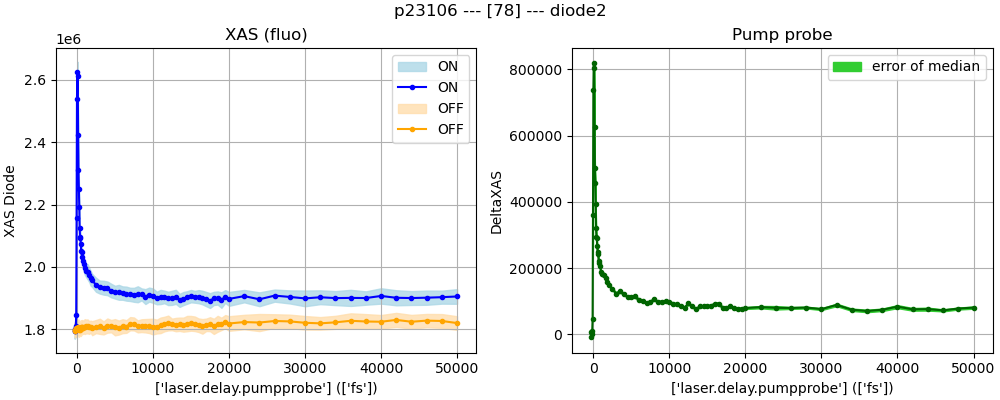

In [104]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.delay_scans(data_plot1, meta, errbars=False)
fig, axes = plotter.delay_scans(data_plot2, meta, errbars=False)

/sf/alvra/data/p23106/work/Reduced_data/
Data saved in /sf/alvra/data/p23106/work/Reduced_data/_multiruns/run0088_0089_0109/


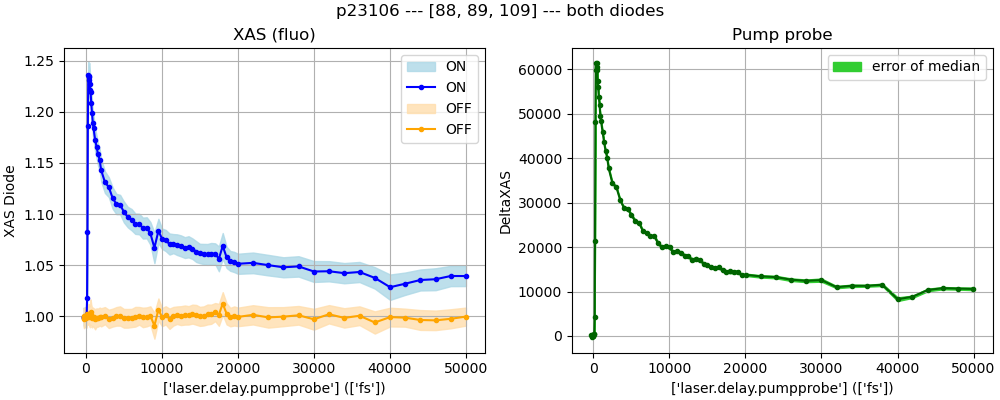

In [136]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.delay_scans(data_plot_both, meta, errbars=False)

In [295]:
#fig, axes = plotter.FFT (data_plot_both, meta, start=0, end=900, errbars=False)

In [74]:
#fig, axes = plotter.fit_risetime(data_plot1, meta, fitflag=True)

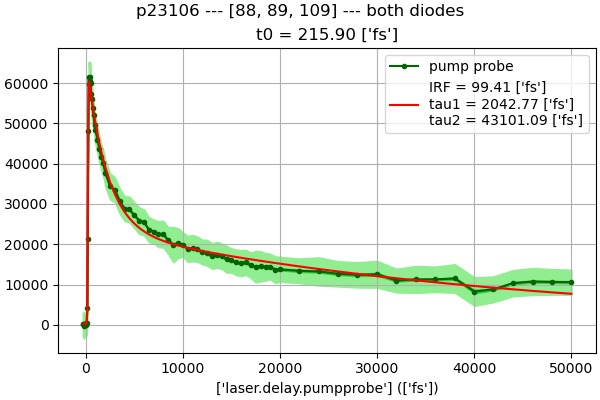

In [137]:
#fig, axes = plotter.fit_decay(data_plot_both, meta, fitfunction=model_decay_1exp, p0 = [0,100,5000, 500,0] )
fig, axes = plotter.fit_decay(data_plot_both, meta, fitfunction=model_decay_2exp, p0 = [0,100,50000, 250,0, 1000, 2500] )

########## model_decay_1exp ##########
###   x0, sigma, amp1, tau1, C
########## model_decay_2exp ##########
###   x0, sigma, amp1, tau1, C, amp2, tau2

# Overlay data with UI

In [154]:
pgroup = 'p23106'
which_plot = 'both' #both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __both diodes__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0020/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0021/data.npz


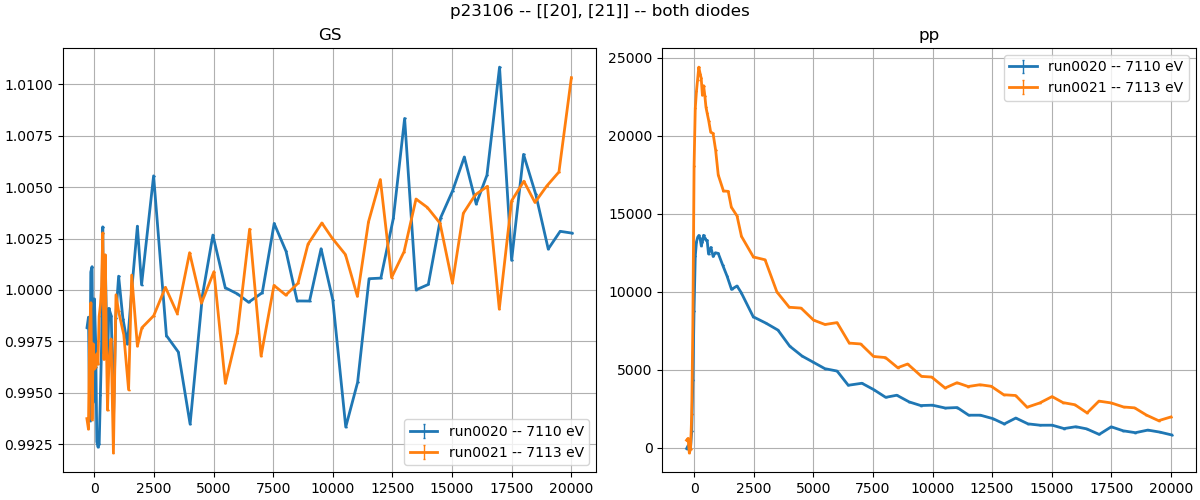

In [155]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

labels = ["7110 eV","7113 eV"]
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS, 0, lw=2,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label + ' -- ' +labels[index])
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=2,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label  + ' -- ' +labels[index])
ax1.legend(loc = 'lower right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
#ax3.set_xlim(-500,2000)
ax3.set_title('pp')
ax3.grid()
plt.show()

In [ ]:
energy_points = np.r_[np.arange(3330,3340,2),np.arange(3340,3345,1),np.arange(3345,3360,0.5), np.arange(3360,3391,1)]
len(energy_points)
print(energy_points.T)

In [344]:
time_values = np.r_[np.arange(-1500,-500,200), np.arange(-500,2000,100), np.arange(2000,10000,500), np.arange(2000,10000,500), np.arange(10000,20000,1000),np.arange(20000,100000,10000),np.arange(100000,1100000,100000)]
len(time_values)

90

In [345]:
print(time_values)

[  -1500   -1300   -1100    -900    -700    -500    -400    -300    -200
    -100       0     100     200     300     400     500     600     700
     800     900    1000    1100    1200    1300    1400    1500    1600
    1700    1800    1900    2000    2500    3000    3500    4000    4500
    5000    5500    6000    6500    7000    7500    8000    8500    9000
    9500    2000    2500    3000    3500    4000    4500    5000    5500
    6000    6500    7000    7500    8000    8500    9000    9500   10000
   11000   12000   13000   14000   15000   16000   17000   18000   19000
   20000   30000   40000   50000   60000   70000   80000   90000  100000
  200000  300000  400000  500000  600000  700000  800000  900000 1000000]


In [341]:
time_values = np.r_[np.arange(-5000,10000,1000), np.arange(10000,20000,2000), np.arange(20000,100000,20000),np.arange(100000,1000000,100000)]
len(time_values)

33

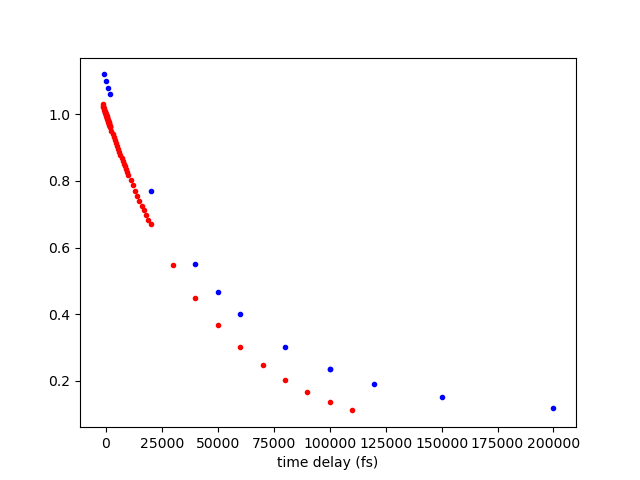

In [261]:
plt.figure()
plt.plot(time_values,np.exp(-time_values/50000),'r.')
plt.plot(time_values_long,np.exp(-time_values_long/50000)+0.1,'b.')
plt.xlabel("time delay (fs)")
plt.show()

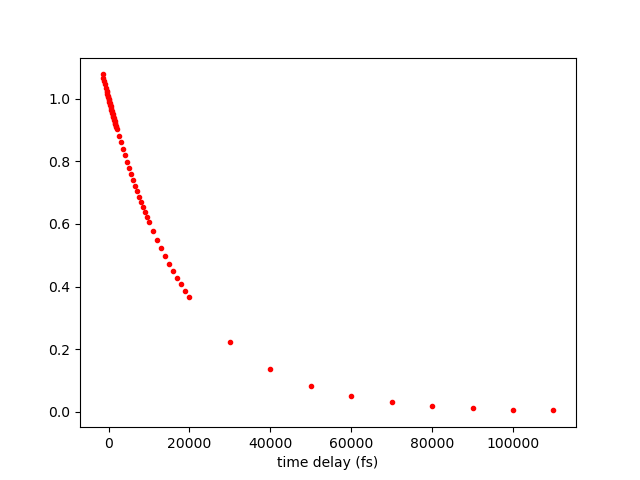

In [231]:
plt.figure()
plt.plot(time_values,np.exp(-time_values/20000),'r.')
plt.xlabel("time delay (fs)")
plt.show()

In [18]:
#time_values_long = np.r_[np.arange(-1000,2100,1000),np.arange(20000,130000,20000),np.arange(50000,260000,50000)]
#len(time_values_long)

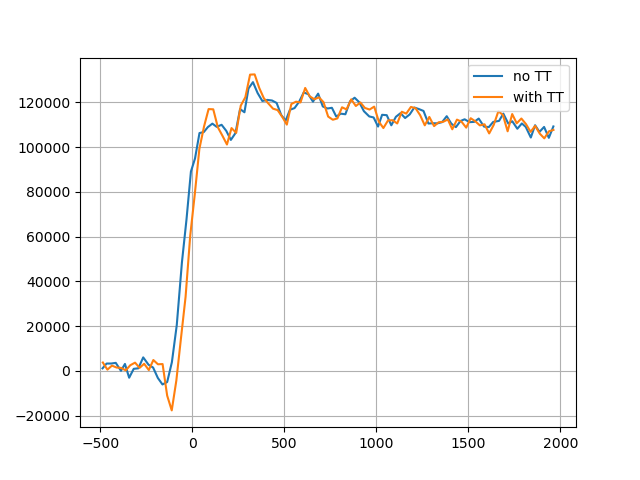

In [107]:
plt.figure()
plt.plot(rbk_noTT, pp_noTT, label = 'no TT')
plt.plot(rbk_withTT, pp_withTT, label = 'with TT')
plt.legend(loc = 'best')
plt.grid()

plt.show()

In [166]:
time_values_ns = np.r_[np.arange(-0.001,0.005,0.001),np.arange(0.1,2,0.1)]
len(time_values_ns)

25

In [167]:
np.set_printoptions(suppress=True)
print(time_values_ns)

[-0.001  0.     0.001  0.002  0.003  0.004  0.1    0.2    0.3    0.4
  0.5    0.6    0.7    0.8    0.9    1.     1.1    1.2    1.3    1.4
  1.5    1.6    1.7    1.8    1.9  ]
